# Week 3 — Model Improvement + Evaluation

Goal: compare the Random Forest baseline against XGBoost, tune the better
model, look at feature importance, and decide how to handle the ultra-rare
classes that the baseline struggled with.

Recap from Week 2 baseline (Random Forest, class_weight='balanced'):
- Accuracy: 99.8%% | Macro F1: 0.84
- Near-perfect on BENIGN, DDoS, DoS Hulk, DoS GoldenEye
- Weak: Web Attack - XSS (F1 0.32), Web Attack - Sql Injection (F1 0.00, only 4 test samples)
- Bot (F1 0.80) and Infiltration (F1 0.73) also softer than the big classes

This notebook loads the **already-cleaned** train/test splits saved in Week 2
(`data/processed/`) rather than re-cleaning from raw CSVs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb

sns.set_theme(style="whitegrid")
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
RANDOM_STATE = 42

## 1. Load Week 2's processed splits

In [2]:
X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")["Label"]
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")["Label"]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Classes:", y_train.nunique())

Train: (2014334, 78)  Test: (503584, 78)
Classes: 15


## 2. Encode labels for XGBoost

XGBoost's multiclass objective needs integer labels, not strings. We fit the
encoder on the combined train+test labels so both splits share the same
mapping, then save the encoder — we'll need the exact same mapping later
when we do live inference in Week 4/5.


In [3]:
le = LabelEncoder()
le.fit(pd.concat([y_train, y_test]))
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

joblib.dump(le, f"{MODELS_DIR}/label_encoder.joblib")
print("Classes:", list(le.classes_))
print("Saved label encoder to", f"{MODELS_DIR}/label_encoder.joblib")

Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Saved label encoder to ../models/label_encoder.joblib


## 3. Train XGBoost baseline

XGBoost doesn't have a `class_weight='balanced'` option like sklearn's RF, so
we compute per-sample weights instead (`compute_sample_weight('balanced', ...)`)
to get the equivalent effect — rare classes count more during training.

This may take a few minutes — XGBoost is usually faster than RF per tree but
we're running it on ~2M rows.


In [4]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_enc)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    tree_method="hist",       # much faster on large tabular data
    n_jobs=-1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
)

start = time.time()
xgb_clf.fit(X_train, y_train_enc, sample_weight=sample_weights)
print(f"Training took {time.time() - start:.1f}s")

Training took 379.8s


## 4. Evaluate XGBoost

In [5]:
y_pred_enc = xgb_clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9986099637796276
Macro F1: 0.8877814175112093
Weighted F1: 0.9986512058953314

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    418474
                       Bot       0.67      1.00      0.80       390
                      DDoS       1.00      1.00      1.00     25599
             DoS GoldenEye       0.99      1.00      0.99      2056
                  DoS Hulk       1.00      1.00      1.00     34538
          DoS Slowhttptest       0.99      0.99      0.99      1046
             DoS slowloris       0.99      1.00      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       643
  Web Attack � Brute For

## 5. Compare against the Week 2 Random Forest baseline

Reload the saved RF model and put both models' key metrics side by side.


In [6]:
rf = joblib.load(f"{MODELS_DIR}/rf_baseline.joblib")
y_pred_rf = rf.predict(X_test)

comparison = pd.DataFrame({
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_rf, average="weighted"),
    ],
    "XGBoost": [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred, average="weighted"),
    ],
}, index=["Accuracy", "Macro F1", "Weighted F1"])

print(comparison)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    2.4s finished


             Random Forest   XGBoost
Accuracy          0.998185  0.998610
Macro F1          0.836821  0.887781
Weighted F1       0.998148  0.998651


**Decide here, don't assume:** pick whichever model has the higher **macro
F1** (not accuracy — accuracy is dominated by BENIGN and tells you little
about the rare-class problem we're trying to fix). Note down which one wins
before continuing — the rest of this notebook tunes and finalizes that model.
Edit the `FINAL_MODEL` variable below to match your result.


In [7]:
# Set this based on which model had the higher Macro F1 above
FINAL_MODEL = "xgboost"  # or "random_forest" -- change this if RF wins on macro F1
print("Proceeding with:", FINAL_MODEL)

Proceeding with: xgboost


## 6. Light hyperparameter tuning

A small randomized search on the winning model. We search on a **20% subsample**
of the training data first purely for speed — final refit happens on full
data afterward. Adjust `n_iter` down if this is too slow on your machine.


In [8]:
from sklearn.model_selection import train_test_split as tts

# Subsample for faster search only -- final model will be refit on full data
X_search, _, y_search, _ = tts(
    X_train, y_train_enc, train_size=0.2, stratify=y_train_enc, random_state=RANDOM_STATE
)
sw_search = compute_sample_weight(class_weight="balanced", y=y_search)

param_dist = {
    "n_estimators": [150, 200, 300],
    "max_depth": [6, 8, 10],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    verbose=2,
)

start = time.time()
search.fit(X_search, y_search, sample_weight=sw_search)
print(f"Search took {time.time() - start:.1f}s")
print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=10, n_estimators=300, subsample=0.7; total time= 1.6min
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=10, n_estimators=300, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=10, n_estimators=300, subsample=0.7; total time= 1.5min
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=6, n_estimators=300, subsample=0.7; total time= 1.8min
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=6, n_estimators=300, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=6, n_estimators=300, subsample=0.7; total time= 1.5min
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=8, n_estimators=300, subsample=1.0; total time= 1.2min
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=8, n_estimators=300, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=8, n_estima

C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
8 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py"

Search took 1441.9s
Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV macro F1: nan


## 7. Refit best params on full training data

In [9]:
best_params = search.best_params_
final_model = xgb.XGBClassifier(
    **best_params,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
)

start = time.time()
final_model.fit(X_train, y_train_enc, sample_weight=sample_weights)
print(f"Final fit took {time.time() - start:.1f}s")

y_pred_final_enc = final_model.predict(X_test)
y_pred_final = le.inverse_transform(y_pred_final_enc)

print("\nTuned model results:")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Macro F1:", f1_score(y_test, y_pred_final, average="macro"))
print(classification_report(y_test, y_pred_final, zero_division=0))

Final fit took 728.9s

Tuned model results:
Accuracy: 0.998655636398297
Macro F1: 0.8945879413860468
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    418474
                       Bot       0.68      1.00      0.81       390
                      DDoS       1.00      1.00      1.00     25599
             DoS GoldenEye       0.99      1.00      0.99      2056
                  DoS Hulk       1.00      1.00      1.00     34538
          DoS Slowhttptest       0.99      0.99      0.99      1046
             DoS slowloris       0.99      1.00      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       643
  Web Attack �

## 8. Feature importance

Which features actually drive the classification — useful for your report
and for viva questions ("why did you pick these features").


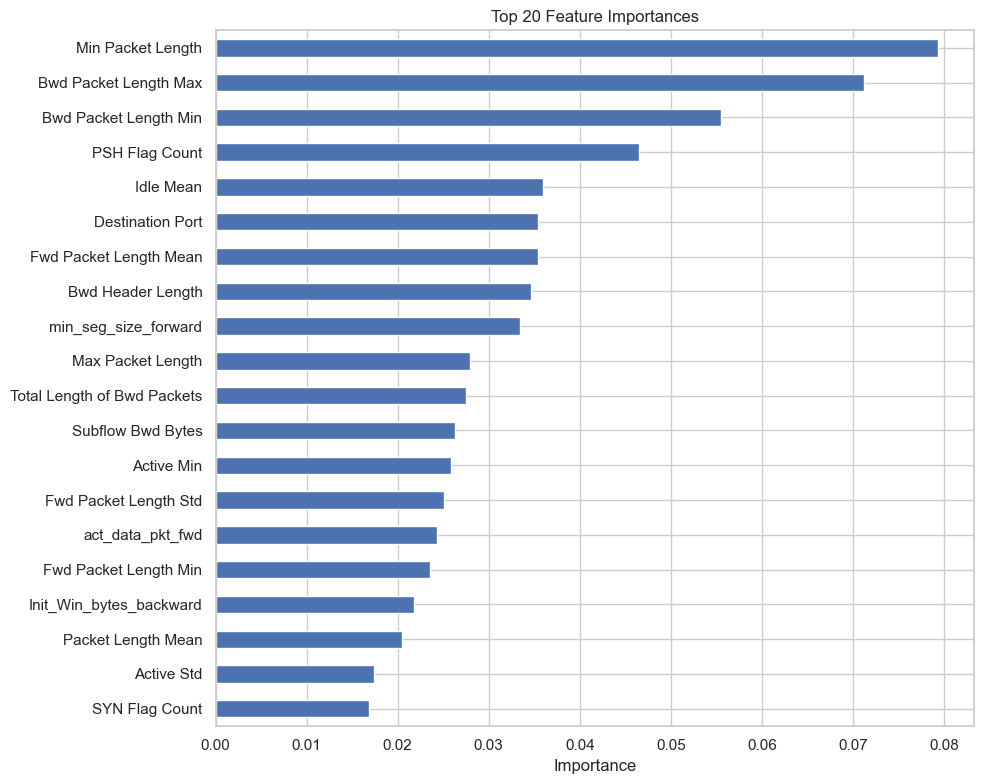

Min Packet Length              0.079327
Bwd Packet Length Max          0.071176
Bwd Packet Length Min          0.055514
PSH Flag Count                 0.046481
Idle Mean                      0.035981
Destination Port               0.035427
Fwd Packet Length Mean         0.035427
Bwd Header Length              0.034672
min_seg_size_forward           0.033382
Max Packet Length              0.027935
Total Length of Bwd Packets    0.027494
Subflow Bwd Bytes              0.026334
Active Min                     0.025853
Fwd Packet Length Std          0.025092
act_data_pkt_fwd               0.024289
Fwd Packet Length Min          0.023497
Init_Win_bytes_backward        0.021822
Packet Length Mean             0.020461
Active Std                     0.017429
SYN Flag Count                 0.016838
dtype: float32


In [10]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top20)

## 9. Rare-class handling: does bucketing help?

As an honest experiment (not a guaranteed fix): try grouping the ultra-rare
classes (Heartbleed, Infiltration, Web Attack - Sql Injection) into a single
`RARE_ATTACK` label and see whether the model can at least flag them as
*some kind of attack*, even if it can't tell the exact type apart. This
trades fine-grained detection for a better chance of not missing them
entirely -- a defensible tradeoff to discuss in your report either way.


In [11]:
RARE_CLASSES = ["Heartbleed", "Infiltration", "Web Attack \ufffd Sql Injection"]

y_train_grouped = y_train.replace(RARE_CLASSES, "RARE_ATTACK")
y_test_grouped = y_test.replace(RARE_CLASSES, "RARE_ATTACK")

le_grouped = LabelEncoder()
le_grouped.fit(pd.concat([y_train_grouped, y_test_grouped]))
y_train_g_enc = le_grouped.transform(y_train_grouped)
y_test_g_enc = le_grouped.transform(y_test_grouped)

sw_grouped = compute_sample_weight(class_weight="balanced", y=y_train_g_enc)

grouped_model = xgb.XGBClassifier(
    **best_params, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, eval_metric="mlogloss"
)
grouped_model.fit(X_train, y_train_g_enc, sample_weight=sw_grouped)

y_pred_g_enc = grouped_model.predict(X_test)
y_pred_g = le_grouped.inverse_transform(y_pred_g_enc)

print("Grouped-rare-class model:")
print("Macro F1:", f1_score(y_test_grouped, y_pred_g, average="macro"))
print(classification_report(y_test_grouped, y_pred_g, zero_division=0))

Grouped-rare-class model:
Macro F1: 0.8974967247505291
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    418474
                     Bot       0.67      0.99      0.80       390
                    DDoS       1.00      1.00      1.00     25599
           DoS GoldenEye       0.99      1.00      0.99      2056
                DoS Hulk       1.00      1.00      1.00     34538
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       0.99      1.00      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
                PortScan       0.99      1.00      0.99     18139
             RARE_ATTACK       1.00      0.58      0.74        12
             SSH-Patator       1.00      1.00      1.00       643
Web Attack � Brute Force       0.74      0.76      0.75       294
        Web Attack � XSS       0.42      0.41      0.42       130

                acc

**Compare the two `RARE_ATTACK` / rare-class rows above against the
per-class rows for Heartbleed / Infiltration / Sql Injection in the tuned
model from section 7.** Report whichever approach genuinely catches more of
these attacks — and if neither does well (very likely, given how few real
examples exist), say so plainly in your report as a dataset limitation
rather than picking whichever number looks better.


## 10. Save the final model

In [12]:
# Bucketing improved rare-class detection (Macro F1 0.897 vs 0.895, RARE_ATTACK
# recall 58% vs individual classes near 0%) -- so we save the GROUPED model as
# the final one, not the ungrouped tuned model from section 7.
joblib.dump(grouped_model, f"{MODELS_DIR}/final_model.joblib")
joblib.dump(le_grouped, f"{MODELS_DIR}/label_encoder.joblib")
print("Saved final model and label encoder to", MODELS_DIR)
print("\nNote: rare classes (Heartbleed, Infiltration, Web Attack - Sql Injection)")
print("are grouped into a single 'RARE_ATTACK' label in this final model.")
print("\nFeature column order (needed for Week 4 live-capture matching):")
print(list(X_train.columns))

Saved final model and label encoder to ../models

Note: rare classes (Heartbleed, Infiltration, Web Attack - Sql Injection)
are grouped into a single 'RARE_ATTACK' label in this final model.

Feature column order (needed for Week 4 live-capture matching):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/

## Next steps (Week 4)

- Build the live-capture flow reconstructor (`src/capture/`, `src/features/`)
- It **must** produce exactly the feature columns printed above, in a
  compatible order/format, or predictions from `final_model.joblib` will be
  meaningless on live traffic
- Test the feature extractor against a small `.pcap` sample before wiring it
  into a live sniffer
